### Nama: Herlinasari
### NIM: 2430109040004
### Mata Kuliah: Pengantar Proses Stokastik

**Import Library**

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

**Definisi Model**

In [15]:
states = ["Baik", "Rusak Ringan", "Rusak Berat"]

transition_matrix = np.array([
    [0.778, 0.167, 0.055],
    [0.429, 0.571, 0.000],
    [0.200, 0.000, 0.800]
])

# Mapping state
state_to_index = {state: i for i, state in enumerate(states)}
index_to_state = {i: state for i, state in enumerate(states)}

**Validasi dan Menampilkan Matriks Transisi**

In [16]:
def validate_transition_matrix(matrix):
    row_sums = matrix.sum(axis=1)

    if np.allclose(row_sums, 1):
        print("Matriks transisi valid")
    else:
        raise ValueError("Jumlah probabilitas setiap baris harus = 1")


validate_transition_matrix(transition_matrix)

transition_df = pd.DataFrame(
    transition_matrix,
    index=states,
    columns=states
)

print("\n=== MATRKS TRANSISI ===")
print(transition_df)


Matriks transisi valid

=== MATRKS TRANSISI ===
               Baik  Rusak Ringan  Rusak Berat
Baik          0.778         0.167        0.055
Rusak Ringan  0.429         0.571        0.000
Rusak Berat   0.200         0.000        0.800


**Klasifikasi State**

In [27]:
import numpy as np

print("\n=== KLASIFIKASI STATE ===")

# 1. Cek Absorbing State (pii = 1)
print("\n[1] Pengecekan Absorbing State:")
has_absorbing = False
for i in range(len(states)):
    pii = transition_matrix[i][i]
    if pii == 1.0:
        print(f"  {states[i]} : Absorbing State (p{i}{i} = 1)")
        has_absorbing = True
    else:
        print(f"  {states[i]} : Non-Absorbing State (p{i}{i} = {pii})")

if not has_absorbing:
    print("  Tidak ada absorbing state pada rantai Markov ini.")

# 2. Cek Irreducible (semua state saling terhubung via BFS/reachability)
print("\n[2] Pengecekan Irreducible (keterhubungan antar state):")

def is_reachable(matrix, start, end, n):
    """Cek apakah state 'end' bisa dicapai dari state 'start'"""
    visited = [False] * n
    queue = [start]
    visited[start] = True
    while queue:
        node = queue.pop(0)
        if node == end:
            return True
        for j in range(n):
            if matrix[node][j] > 0 and not visited[j]:
                visited[j] = True
                queue.append(j)
    return False

n_states = len(states)
irreducible = True
for i in range(n_states):
    for j in range(n_states):
        if i != j:
            if not is_reachable(transition_matrix, i, j, n_states):
                print(f"  State {states[i]} TIDAK bisa mencapai {states[j]}")
                irreducible = False

if irreducible:
    print("  Semua state saling dapat dicapai satu sama lain.")
    print("  : Rantai Markov bersifat IRREDUCIBLE.")
else:
    print("  : Rantai Markov TIDAK irreducible (reducible).")

# 3. Klasifikasi Recurrent vs Transient
print("\n[3] Klasifikasi Recurrent / Transient:")
if irreducible:
    print("  Karena rantai bersifat irreducible dan finite,")
    print("  maka SEMUA state bersifat RECURRENT (pasti kembali ke state asal).")
    for s in states:
        print(f"  {s} : Recurrent State")
else:
    print("  Perlu analisis lebih lanjut per state.")

print("\n[Ringkasan Klasifikasi State]")
for s in states:
    print(f"  {s}: Non-Absorbing, Recurrent, Irreducible")


=== KLASIFIKASI STATE ===

[1] Pengecekan Absorbing State:
  Baik : Non-Absorbing State (p00 = 0.778)
  Rusak Ringan : Non-Absorbing State (p11 = 0.571)
  Rusak Berat : Non-Absorbing State (p22 = 0.8)
  Tidak ada absorbing state pada rantai Markov ini.

[2] Pengecekan Irreducible (keterhubungan antar state):
  Semua state saling dapat dicapai satu sama lain.
  : Rantai Markov bersifat IRREDUCIBLE.

[3] Klasifikasi Recurrent / Transient:
  Karena rantai bersifat irreducible dan finite,
  maka SEMUA state bersifat RECURRENT (pasti kembali ke state asal).
  Baik : Recurrent State
  Rusak Ringan : Recurrent State
  Rusak Berat : Recurrent State

[Ringkasan Klasifikasi State]
  Baik: Non-Absorbing, Recurrent, Irreducible
  Rusak Ringan: Non-Absorbing, Recurrent, Irreducible
  Rusak Berat: Non-Absorbing, Recurrent, Irreducible


**Perhitungan Distribusi Stasioner**

In [18]:

def calculate_steady_state(matrix):

    n = matrix.shape[0]

    A = matrix.T - np.eye(n)

    # Ganti baris terakhir menjadi 1
    A[-1] = np.ones(n)

    b = np.zeros(n)
    b[-1] = 1

    steady_state = np.linalg.solve(A, b)

    return steady_state


steady_state = calculate_steady_state(transition_matrix)

steady_state_df = pd.DataFrame({
    "State": states,
    "Probabilitas": steady_state
})

print("\n=== DISTRIBUSI STASIONER ===")
print(steady_state_df)


=== DISTRIBUSI STASIONER ===
          State  Probabilitas
0          Baik      0.600861
1  Rusak Ringan      0.233902
2   Rusak Berat      0.165237


**Analisis Reliability**

In [19]:
# Reliable states:
# Baik + Rusak Ringan

reliability = steady_state[0] + steady_state[1]

print("\n=== ANALISIS KEANDALAN ===")
print(f"Reliability System = {reliability:.4f}")
print(f"Persentase Keandalan = {reliability*100:.2f}%")


=== ANALISIS KEANDALAN ===
Reliability System = 0.8348
Persentase Keandalan = 83.48%


**Simulasi DTMC**

In [20]:
def next_state(current_state):

    current_index = state_to_index[current_state]

    probabilities = transition_matrix[current_index]

    next_index = random.choices(
        range(len(states)),
        weights=probabilities,
        k=1
    )[0]

    return index_to_state[next_index]


def simulate_markov_chain(initial_state, days):

    current_state = initial_state

    history = [current_state]

    for _ in range(days):

        new_state = next_state(current_state)

        history.append(new_state)

        current_state = new_state

    return history


simulation_days = 30

simulation_result = simulate_markov_chain(
    initial_state="Baik",
    days=simulation_days
)

print("\n=== HASIL SIMULASI 30 HARI ===")

for day, state in enumerate(simulation_result):
    print(f"Hari ke-{day}: {state}")



=== HASIL SIMULASI 30 HARI ===
Hari ke-0: Baik
Hari ke-1: Baik
Hari ke-2: Baik
Hari ke-3: Rusak Ringan
Hari ke-4: Rusak Ringan
Hari ke-5: Baik
Hari ke-6: Baik
Hari ke-7: Baik
Hari ke-8: Baik
Hari ke-9: Rusak Ringan
Hari ke-10: Rusak Ringan
Hari ke-11: Rusak Ringan
Hari ke-12: Baik
Hari ke-13: Baik
Hari ke-14: Baik
Hari ke-15: Baik
Hari ke-16: Rusak Ringan
Hari ke-17: Rusak Ringan
Hari ke-18: Rusak Ringan
Hari ke-19: Rusak Ringan
Hari ke-20: Baik
Hari ke-21: Baik
Hari ke-22: Baik
Hari ke-23: Baik
Hari ke-24: Baik
Hari ke-25: Baik
Hari ke-26: Rusak Berat
Hari ke-27: Rusak Berat
Hari ke-28: Rusak Berat
Hari ke-29: Rusak Berat
Hari ke-30: Baik


**Frekuensi State Hasil Simulasi**

In [21]:
simulation_df = pd.DataFrame({
    "Hari": range(len(simulation_result)),
    "State": simulation_result
})

frequency = simulation_df["State"].value_counts()

print("\n=== FREKUENSI KONDISI MESIN ===")
print(frequency)


=== FREKUENSI KONDISI MESIN ===
State
Baik            18
Rusak Ringan     9
Rusak Berat      4
Name: count, dtype: int64


**Visualisasi Distribusi Stasioner**

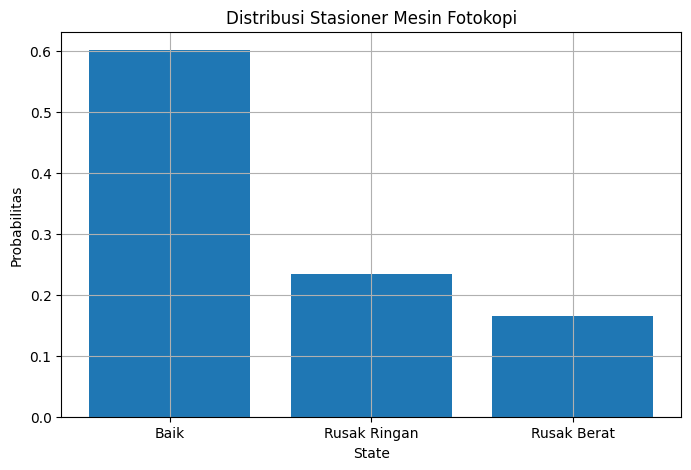

In [22]:
plt.figure(figsize=(8,5))

plt.bar(states, steady_state)

plt.title("Distribusi Stasioner Mesin Fotokopi")
plt.ylabel("Probabilitas")
plt.xlabel("State")

plt.grid(True)

plt.show()

**Visualisasi Simulasi 30 Hari**

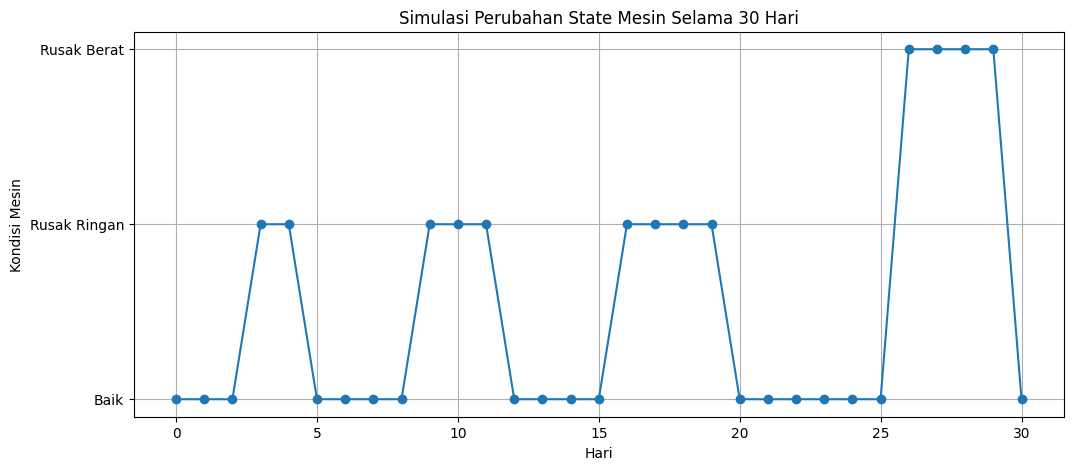

In [23]:
numeric_states = [
    state_to_index[state]
    for state in simulation_result
]

plt.figure(figsize=(12,5))

plt.plot(
    range(len(numeric_states)),
    numeric_states,
    marker='o'
)

plt.yticks([0,1,2], states)

plt.title("Simulasi Perubahan State Mesin Selama 30 Hari")
plt.xlabel("Hari")
plt.ylabel("Kondisi Mesin")

plt.grid(True)

plt.show()

**Heatmap Matriks Transisi**

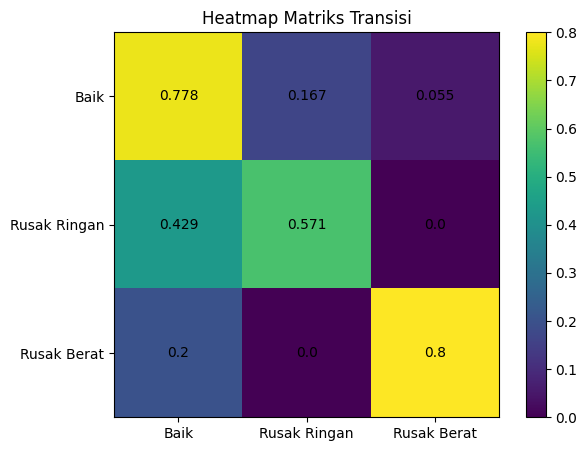

In [24]:
plt.figure(figsize=(7,5))

plt.imshow(transition_matrix)

plt.colorbar()

plt.xticks(range(len(states)), states)
plt.yticks(range(len(states)), states)

plt.title("Heatmap Matriks Transisi")

for i in range(len(states)):
    for j in range(len(states)):
        plt.text(
            j,
            i,
            transition_matrix[i, j],
            ha='center',
            va='center'
        )

plt.show()

**Probabilitas n-langkah**

In [25]:
n = 5

P_n = np.linalg.matrix_power(transition_matrix, n)

Pn_df = pd.DataFrame(
    P_n,
    index=states,
    columns=states
)

print(f"\n=== PROBABILITAS TRANSISI {n}-LANGKAH ===")
print(Pn_df)


=== PROBABILITAS TRANSISI 5-LANGKAH ===
                  Baik  Rusak Ringan  Rusak Berat
Baik          0.621394      0.246683     0.131922
Rusak Ringan  0.633695      0.271364     0.094941
Rusak Berat   0.479718      0.134394     0.385888


**Interpretasi Hasil**

In [26]:
print("\n=== INTERPRETASI ===")

print(
    f"""
Distribusi stasioner menunjukkan bahwa dalam jangka panjang:

- Mesin berada pada kondisi baik sebesar {steady_state[0]*100:.2f}%
- Mesin berada pada kondisi rusak ringan sebesar {steady_state[1]*100:.2f}%
- Mesin berada pada kondisi rusak berat sebesar {steady_state[2]*100:.2f}%

Nilai reliability sebesar {reliability*100:.2f}% menunjukkan bahwa
mesin masih memiliki tingkat keandalan yang cukup baik untuk mendukung
operasional usaha fotokopi.
"""
)

print("=== ANALISIS SELESAI ===")


=== INTERPRETASI ===

Distribusi stasioner menunjukkan bahwa dalam jangka panjang:

- Mesin berada pada kondisi baik sebesar 60.09%
- Mesin berada pada kondisi rusak ringan sebesar 23.39%
- Mesin berada pada kondisi rusak berat sebesar 16.52%

Nilai reliability sebesar 83.48% menunjukkan bahwa
mesin masih memiliki tingkat keandalan yang cukup baik untuk mendukung
operasional usaha fotokopi.

=== ANALISIS SELESAI ===
